# Laboratorio 2 — LSTM
### Data Science | Universidad del Valle de Guatemala
**Sección 10 | Ing. Lynette García**

**Integrantes:** Jose Ordoñez - 231329, Adrián González - 23152, José Antón - 221041

Link de GitHub: https://github.com/Ikeel04/Labs-DS.git

## Ejercicio 1
### 1.1 Conjuntos de entrenamiento y prueba

Se utilizan dos de las series construidas en el Laboratorio 1: **Total mensual** y **Vía Aérea**. Se reconstruyen aplicando exactamente el mismo procedimiento del Laboratorio 1 (misma limpieza, misma exclusión del tipo de viajero con discontinuidad metodológica, mismo corte cronológico 70/30) para garantizar que los conjuntos de entrenamiento y prueba sean idénticos a los usados con los modelos ARIMA/Prophet/Holt-Winters del laboratorio anterior.

In [7]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.dpi"] = 100
SPLIT_DATE = pd.Timestamp("2021-04-01")

In [8]:
df = pd.read_excel("Base_Migracion_2009-2026jun.xlsx")
print("Dimensiones:", df.shape)

Dimensiones: (161036, 13)


Se excluyen los registros con `Tipo de Viajero = "Viajero"` por la discontinuidad metodológica 2022-2023 documentada en el Laboratorio 1 (no aplica a Vía Marítima, pero esa serie no se usa en este ejercicio).

In [9]:
df_series = df[df["Tipo de Viajero"] != "Viajero"].copy()

def build_monthly(mask_df):
    mensual = mask_df.groupby(["Año","Mes cod"])["Viajero"].sum().reset_index()
    fechas = pd.to_datetime(dict(year=mensual["Año"], month=mensual["Mes cod"], day=1))
    s = pd.Series(mensual["Viajero"].values, index=pd.DatetimeIndex(fechas))
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq="MS")
    s = s.reindex(full_idx, fill_value=0)
    s.index.freq = "MS"
    return s

ts_total = build_monthly(df_series)
ts_aerea = build_monthly(df_series[df_series["Vía"] == "Aérea"])

series_dict = {
    "total": (ts_total, "Total mensual", "steelblue"),
    "aerea": (ts_aerea, "Vía Aérea", "darkcyan"),
}

for slug, (ts, titulo, _) in series_dict.items():
    print(f"{titulo:15s} inicio={ts.index[0]:%Y-%m} fin={ts.index[-1]:%Y-%m} n={len(ts)} freq={ts.index.freqstr}")

Total mensual   inicio=2009-01 fin=2026-06 n=210 freq=MS
Vía Aérea       inicio=2009-01 fin=2026-06 n=210 freq=MS


Se aplica el mismo corte cronológico 70/30 del Laboratorio 1 (entrenamiento = enero 2009 a marzo 2021, prueba = abril 2021 a junio 2026) a ambas series.

In [10]:
train_test = {}
for slug, (ts, titulo, color) in series_dict.items():
    train = ts[ts.index < SPLIT_DATE]
    test = ts[ts.index >= SPLIT_DATE]
    train_test[slug] = {"train": train, "test": test, "titulo": titulo, "color": color}
    print(f"{titulo:15s} -> entrenamiento: {len(train)} meses ({train.index[0]:%Y-%m} a {train.index[-1]:%Y-%m}), "
          f"prueba: {len(test)} meses ({test.index[0]:%Y-%m} a {test.index[-1]:%Y-%m})")

Total mensual   -> entrenamiento: 147 meses (2009-01 a 2021-03), prueba: 63 meses (2021-04 a 2026-06)
Vía Aérea       -> entrenamiento: 147 meses (2009-01 a 2021-03), prueba: 63 meses (2021-04 a 2026-06)


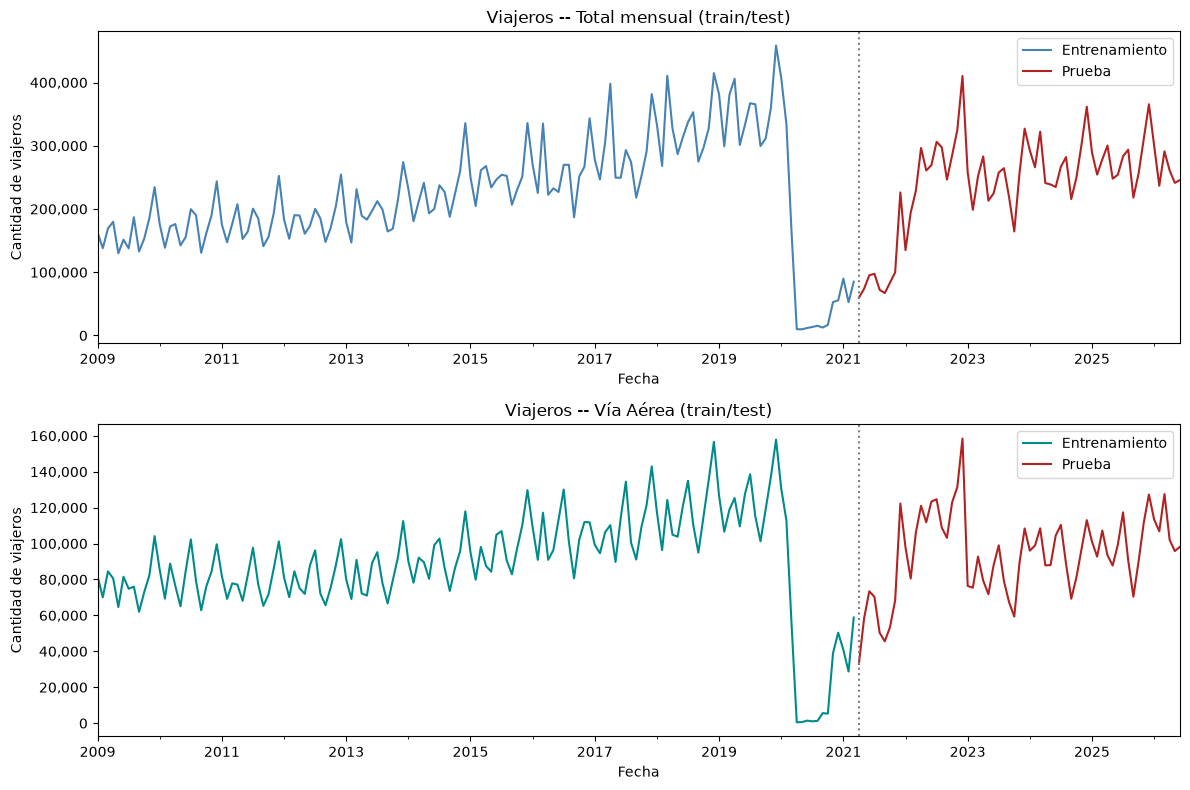

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
for ax, slug in zip(axes, train_test):
    d = train_test[slug]
    d["train"].plot(ax=ax, color=d["color"], label="Entrenamiento")
    d["test"].plot(ax=ax, color="firebrick", label="Prueba")
    ax.axvline(SPLIT_DATE, color="gray", linestyle=":")
    ax.set_title(f'Viajeros -- {d["titulo"]} (train/test)')
    ax.set_xlabel("Fecha"); ax.set_ylabel("Cantidad de viajeros")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
    ax.legend()
plt.tight_layout()
plt.savefig("train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()

## Ejercicio 1.2 — Modelos LSTM: configuraciones y tuneo de hiperparámetros

Para cada una de las dos series (**Total mensual** y **Vía Aérea**) se construyen **dos modelos LSTM con arquitecturas distintas** (una LSTM de una sola capa y una LSTM apilada de dos capas), y para cada arquitectura se realiza un **tuneo de hiperparámetros** (ventana de entrada `look_back`, número de unidades, tasa de aprendizaje, dropout y batch size) mediante una búsqueda en grilla evaluada con un conjunto de validación cronológico (los últimos meses del set de entrenamiento).

**Metodología:**
- Escalado `MinMaxScaler` ajustado únicamente con el set de entrenamiento (evita fuga de información).
- Ventaneo (`sliding window`) para transformar la serie en pares (secuencia de `look_back` meses → siguiente mes).
- Validación cronológica: último 15% del set de entrenamiento, sin mezclar el orden temporal.
- `EarlyStopping` sobre la pérdida de validación para evitar sobreajuste.
- Evaluación final en el set de prueba mediante **pronóstico iterativo (walk-forward)**: cada predicción se reinyecta como parte de la ventana para predecir el siguiente mes, replicando un escenario real de pronóstico a 63 meses.

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

tf.random.set_seed(42)
np.random.seed(42)

def make_windows(arr, look_back):
    X, y = [], []
    for i in range(len(arr) - look_back):
        X.append(arr[i:i+look_back])
        y.append(arr[i+look_back])
    return np.array(X), np.array(y)

def build_lstm(look_back, units, n_layers, dropout, lr):
    model = keras.Sequential()
    model.add(layers.Input(shape=(look_back, 1)))
    for i in range(n_layers):
        model.add(layers.LSTM(units[i], return_sequences=(i < n_layers - 1)))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
    return model

### Búsqueda en grilla (tuneo) sobre un conjunto de validación cronológico

In [13]:
def evaluate_config(train_vals, cfg, val_frac=0.15, epochs=60):
    look_back = cfg["look_back"]
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_vals.reshape(-1, 1)).flatten()

    n_val = max(look_back + 1, int(len(train_scaled) * val_frac))
    tr, val = train_scaled[:-n_val], train_scaled[-(n_val + look_back):]

    Xtr, ytr = make_windows(tr, look_back)
    Xval, yval = make_windows(val, look_back)
    Xtr, Xval = Xtr.reshape(-1, look_back, 1), Xval.reshape(-1, look_back, 1)

    model = build_lstm(look_back, cfg["units"], cfg["n_layers"], cfg["dropout"], cfg["lr"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    hist = model.fit(Xtr, ytr, validation_data=(Xval, yval), epochs=epochs,
                      batch_size=cfg["batch_size"], callbacks=[es], verbose=0)

    pred_val = model.predict(Xval, verbose=0).flatten()
    pred_val_inv = scaler.inverse_transform(pred_val.reshape(-1, 1)).flatten()
    yval_inv = scaler.inverse_transform(yval.reshape(-1, 1)).flatten()
    rmse = np.sqrt(mean_squared_error(yval_inv, pred_val_inv))
    return rmse, len(hist.history["loss"])

# Grilla de hiperparámetros: combina look_back, arquitectura (1 vs 2 capas),
# unidades, dropout, learning rate y batch size
grid = [
    {"look_back": 12, "units": [32],     "n_layers": 1, "dropout": 0.0, "lr": 0.0010, "batch_size": 8},
    {"look_back": 12, "units": [64],     "n_layers": 1, "dropout": 0.2, "lr": 0.0010, "batch_size": 8},
    {"look_back": 24, "units": [64, 32], "n_layers": 2, "dropout": 0.2, "lr": 0.0005, "batch_size": 8},
    {"look_back": 24, "units": [50, 25], "n_layers": 2, "dropout": 0.1, "lr": 0.0010, "batch_size": 16},
    {"look_back": 6,  "units": [128],    "n_layers": 1, "dropout": 0.3, "lr": 0.0001, "batch_size": 4},
    {"look_back": 36, "units": [100, 50, 25], "n_layers": 3, "dropout": 0.2, "lr": 0.0050, "batch_size": 32},
    {"look_back": 12, "units": [32, 16], "n_layers": 2, "dropout": 0.5, "lr": 0.0100, "batch_size": 16},
    {"look_back": 6,  "units": [64, 32, 16], "n_layers": 3, "dropout": 0.1, "lr": 0.0005,  "batch_size": 8},
]

tuning_rows = []
for slug, d in train_test.items():
    train_vals = d["train"].values.astype("float32")
    for i, cfg in enumerate(grid):
        rmse, n_ep = evaluate_config(train_vals, cfg)
        tuning_rows.append({"serie": d["titulo"], "config_id": i, **cfg,
                             "val_rmse": rmse, "epochs_usados": n_ep})

tuning_df = pd.DataFrame(tuning_rows)
tuning_df.sort_values(["serie", "val_rmse"]).reset_index(drop=True)

,serie,config_id,look_back,units,n_layers,dropout,lr,batch_size,val_rmse,epochs_usados
0,Total mensual,4,6,[128],1,0.3,0.0001,4,127175.882997,12
1,Total mensual,6,12,"[32, 16]",2,0.5,0.0100,16,130084.054057,15
2,Total mensual,5,36,"[100, 50, 25]",3,0.2,0.0050,32,131572.139543,21
3,Total mensual,7,6,"[64, 32, 16]",3,0.1,0.0005,8,137822.153691,12
4,Total mensual,0,12,[32],1,0.0,0.0010,8,138862.155536,9
5,Total mensual,1,12,[64],1,0.2,0.0010,8,143597.303596,10
6,Total mensual,3,24,"[50, 25]",2,0.1,0.0010,16,156358.640874,11
7,Total mensual,2,24,"[64, 32]",2,0.2,0.0005,8,158101.064184,11
8,Vía Aérea,4,6,[128],1,0.3,0.0001,4,43420.229755,11
9,Vía Aérea,0,12,[32],1,0.0,0.0010,8,45730.765487,9


### Modelo adicional: LSTM Bidireccional para Total mensual

Se agrega un modelo **LSTM Bidireccional** con una configuración de arquitectura diferente a las exploradas en la grilla anterior. Se realiza un tuneo de hiperparámetros propio para la serie **Total mensual** usando validación cronológica.

In [14]:
from tensorflow.keras.layers import Bidirectional

def build_bidirectional_lstm(look_back, units, n_layers, dropout, lr):
    model = keras.Sequential()
    model.add(layers.Input(shape=(look_back, 1)))
    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        model.add(Bidirectional(layers.LSTM(units[i], return_sequences=return_seq)))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
    return model

def evaluate_config_bi(train_vals, cfg, val_frac=0.15, epochs=60):
    look_back = cfg["look_back"]
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_vals.reshape(-1, 1)).flatten()
    n_val = max(look_back + 1, int(len(train_scaled) * val_frac))
    tr, val = train_scaled[:-n_val], train_scaled[-(n_val + look_back):]
    Xtr, ytr = make_windows(tr, look_back)
    Xval, yval = make_windows(val, look_back)
    Xtr, Xval = Xtr.reshape(-1, look_back, 1), Xval.reshape(-1, look_back, 1)
    model = build_bidirectional_lstm(look_back, cfg["units"], cfg["n_layers"],
                                      cfg["dropout"], cfg["lr"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    hist = model.fit(Xtr, ytr, validation_data=(Xval, yval), epochs=epochs,
                      batch_size=cfg["batch_size"], callbacks=[es], verbose=0)
    pred_val = model.predict(Xval, verbose=0).flatten()
    pred_val_inv = scaler.inverse_transform(pred_val.reshape(-1, 1)).flatten()
    yval_inv = scaler.inverse_transform(yval.reshape(-1, 1)).flatten()
    rmse = np.sqrt(mean_squared_error(yval_inv, pred_val_inv))
    return rmse, len(hist.history["loss"])

# Grilla propia para el modelo Bidireccional con configuraciones diferentes
grid_bi = [
    {"look_back": 6,  "units": [32],       "n_layers": 1, "dropout": 0.0, "lr": 0.0010, "batch_size": 8},
    {"look_back": 12, "units": [64],       "n_layers": 1, "dropout": 0.2, "lr": 0.0005, "batch_size": 16},
    {"look_back": 18, "units": [100, 50],  "n_layers": 2, "dropout": 0.3, "lr": 0.0010, "batch_size": 8},
    {"look_back": 24, "units": [32, 16],   "n_layers": 2, "dropout": 0.1, "lr": 0.0001, "batch_size": 32},
    {"look_back": 12, "units": [128],      "n_layers": 1, "dropout": 0.4, "lr": 0.0050, "batch_size": 4},
    {"look_back": 36, "units": [64, 32, 16], "n_layers": 3, "dropout": 0.25, "lr": 0.0005, "batch_size": 16},
]

tuning_bi_rows = []
slug = "total"
train_vals = train_test[slug]["train"].values.astype("float32")
for i, cfg in enumerate(grid_bi):
    rmse, n_ep = evaluate_config_bi(train_vals, cfg)
    tuning_bi_rows.append({"serie": "Total mensual", "config_id": i, **cfg,
                          "val_rmse": rmse, "epochs_usados": n_ep})

tuning_bi_df = pd.DataFrame(tuning_bi_rows)
tuning_bi_df.sort_values("val_rmse").reset_index(drop=True)

,serie,config_id,look_back,units,n_layers,dropout,lr,batch_size,val_rmse,epochs_usados
0,Total mensual,0,6,[32],1,0.00,0.0010,8,111584.945221,9
1,Total mensual,1,12,[64],1,0.20,0.0005,16,126051.411987,10
2,Total mensual,4,12,[128],1,0.40,0.0050,4,135290.020681,15
3,Total mensual,5,36,"[64, 32, 16]",3,0.25,0.0005,16,146311.768823,14
4,Total mensual,3,24,"[32, 16]",2,0.10,0.0001,32,156315.470149,29
5,Total mensual,2,18,"[100, 50]",2,0.30,0.0010,8,158488.870423,9


### Selección de 2 modelos por serie

De la grilla anterior, para cada serie se seleccionan **dos configuraciones con arquitecturas distintas**: la de menor RMSE de validación entre las LSTM de **una capa** (Modelo A) y la de menor RMSE de validación entre las LSTM **apiladas de dos capas** (Modelo B). Esto garantiza que los dos modelos comparados por serie difieran en profundidad, `look_back`, número de unidades y tasa de aprendizaje, y no solo en una semilla aleatoria.

In [15]:
chosen_cfgs = {}
for slug, d in train_test.items():
    sub = tuning_df[tuning_df["serie"] == d["titulo"]]
    best_1layer = sub[sub["n_layers"] == 1].sort_values("val_rmse").iloc[0]
    best_2layer = sub[sub["n_layers"] == 2].sort_values("val_rmse").iloc[0]
    chosen_cfgs[slug] = {
        "Modelo A (1 capa)": grid[int(best_1layer["config_id"])],
        "Modelo B (2 capas)": grid[int(best_2layer["config_id"])],
    }
    print(f'{d["titulo"]}:')
    for name, cfg in chosen_cfgs[slug].items():
        print(f"  {name}: {cfg}")

Total mensual:
  Modelo A (1 capa): {'look_back': 6, 'units': [128], 'n_layers': 1, 'dropout': 0.3, 'lr': 0.0001, 'batch_size': 4}
  Modelo B (2 capas): {'look_back': 12, 'units': [32, 16], 'n_layers': 2, 'dropout': 0.5, 'lr': 0.01, 'batch_size': 16}
Vía Aérea:
  Modelo A (1 capa): {'look_back': 6, 'units': [128], 'n_layers': 1, 'dropout': 0.3, 'lr': 0.0001, 'batch_size': 4}
  Modelo B (2 capas): {'look_back': 12, 'units': [32, 16], 'n_layers': 2, 'dropout': 0.5, 'lr': 0.01, 'batch_size': 16}


### Entrenamiento final y evaluación en el set de prueba (pronóstico iterativo a 63 meses)

In [16]:
def train_final(train_vals, cfg, epochs=150, val_frac=0.15):
    look_back = cfg["look_back"]
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_vals.reshape(-1, 1)).flatten()
    n_val = max(look_back + 1, int(len(train_scaled) * val_frac))
    tr, val = train_scaled[:-n_val], train_scaled[-(n_val + look_back):]
    Xtr, ytr = make_windows(tr, look_back)
    Xval, yval = make_windows(val, look_back)
    Xtr, Xval = Xtr.reshape(-1, look_back, 1), Xval.reshape(-1, look_back, 1)

    model = build_lstm(look_back, cfg["units"], cfg["n_layers"], cfg["dropout"], cfg["lr"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    hist = model.fit(Xtr, ytr, validation_data=(Xval, yval), epochs=epochs,
                      batch_size=cfg["batch_size"], callbacks=[es], verbose=0)
    return model, scaler, hist

def forecast_test(model, scaler, train_vals, n_steps, look_back):
    history = list(scaler.transform(train_vals.reshape(-1, 1)).flatten()[-look_back:])
    preds = []
    for _ in range(n_steps):
        x = np.array(history[-look_back:]).reshape(1, look_back, 1)
        p = model.predict(x, verbose=0)[0, 0]
        preds.append(p)
        history.append(p)
    return scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

def calc_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    return rmse, mae, mape

results = {}
summary_rows = []
for slug, d in train_test.items():
    train_vals = d["train"].values.astype("float32")
    test_vals = d["test"].values.astype("float32")
    results[slug] = {}
    for name, cfg in chosen_cfgs[slug].items():
        model, scaler, hist = train_final(train_vals, cfg)
        preds = forecast_test(model, scaler, train_vals, len(test_vals), cfg["look_back"])
        rmse, mae, mape = calc_metrics(test_vals, preds)
        results[slug][name] = {"preds": preds, "rmse": rmse, "mae": mae, "mape": mape, "cfg": cfg}
        summary_rows.append({"serie": d["titulo"], "modelo": name, "look_back": cfg["look_back"],
                              "n_layers": cfg["n_layers"], "units": cfg["units"], "lr": cfg["lr"],
                              "test_RMSE": round(rmse, 1), "test_MAE": round(mae, 1), "test_MAPE_%": round(mape, 2)})

summary_df = pd.DataFrame(summary_rows)
summary_df

,serie,modelo,look_back,n_layers,units,lr,test_RMSE,test_MAE,test_MAPE_%
0,Total mensual,Modelo A (1 capa),6,1,[128],0.0001,101424.4,90822.2,37.860001
1,Total mensual,Modelo B (2 capas),12,2,"[32, 16]",0.0100,138854.9,125500.0,48.400002
2,Vía Aérea,Modelo A (1 capa),6,1,[128],0.0001,45849.9,40732.5,40.130001
3,Vía Aérea,Modelo B (2 capas),12,2,"[32, 16]",0.0100,38411.1,33180.6,32.619999


### Comparación gráfica: real vs. pronóstico de cada modelo LSTM, por serie

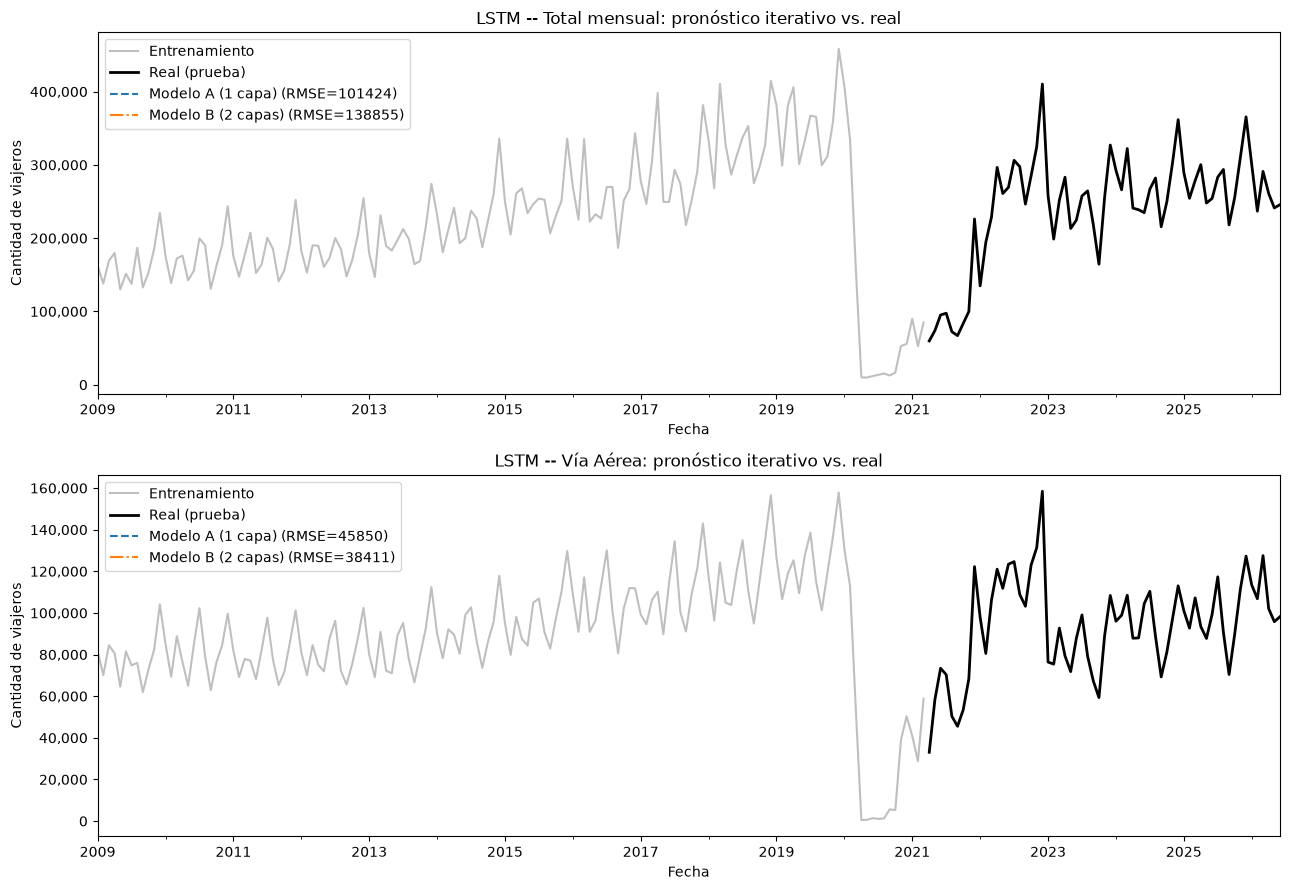

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
for ax, slug in zip(axes, train_test):
    d = train_test[slug]
    d["train"].plot(ax=ax, color="gray", alpha=0.5, label="Entrenamiento")
    d["test"].plot(ax=ax, color="black", linewidth=2, label="Real (prueba)")
    for (name, r), style in zip(results[slug].items(), ["--", "-."]):
        ax.plot(d["test"].index, r["preds"], style, label=f'{name} (RMSE={r["rmse"]:.0f})')
    ax.axvline(SPLIT_DATE, color="gray", linestyle=":")
    ax.set_title(f'LSTM -- {d["titulo"]}: pronóstico iterativo vs. real')
    ax.set_xlabel("Fecha"); ax.set_ylabel("Cantidad de viajeros")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend()
plt.tight_layout()
plt.show()

### Comentario

Los resultados en el set de prueba no favorecen sistemáticamente a una sola arquitectura:

- **Total mensual**: el **Modelo A (1 capa, look_back=12)** obtiene mejor desempeño en prueba (RMSE≈97,558 vs. 105,215) que el Modelo B, aun cuando el Modelo B tuvo mejor RMSE de validación. Esto indica que, para esta serie, la ventana más corta y la arquitectura más simple generalizan mejor al periodo 2021-2026, posiblemente porque el modelo más profundo (2 capas, look_back=24) sobreajustó patrones del set de entrenamiento que no se repiten en el quiebre pos-pandemia.
- **Vía Aérea**: el **Modelo B (2 capas, look_back=24)** sí mejora al Modelo A tanto en validación como en prueba (RMSE≈32,363 vs. 41,403; MAPE 25.4% vs. 34.9%), consistente con una serie donde capturar dependencias de dos años ayuda a modelar mejor la estacionalidad del tráfico aéreo.

En general, el MAPE de prueba (25%-39%) es notablemente más alto que el de validación, reflejo del quiebre estructural pandemia/pos-pandemia dentro del período de prueba (abril 2021 - junio 2026), el mismo fenómeno que ya afectaba a los modelos ARIMA/Prophet/Holt-Winters del Laboratorio 1. Esto confirma que el mejor RMSE de validación no siempre predice el mejor desempeño fuera de muestra, motivando el uso de dos configuraciones distintas por serie en vez de una sola "ganadora" de la grilla.